In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/14-income_evaluation.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [4]:
col_names = ['age', 'workclass', 'finalweight', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [5]:
df.columns = col_names

In [6]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
categorical = [col for col in df.columns if df[col].dtype == "O"]
numerical = [col for col in df.columns if df[col].dtype != "O"]

In [11]:
print(categorical)
print(numerical)

['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
['age', 'finalweight', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [12]:
df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [13]:
for col in categorical:
    print(df[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

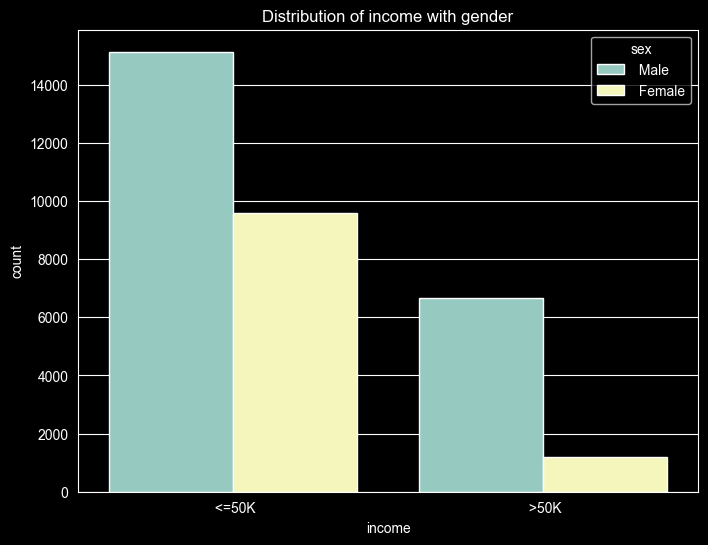

In [14]:
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x = "income", hue = "sex", data=df)
ax.set_title("Distribution of income with gender")
plt.show()

In [15]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [16]:
df["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [17]:
df['workclass'] = df['workclass'].replace(' ?', np.NaN)

In [18]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [19]:
df["occupation"].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [20]:
df['occupation'] = df['occupation'].replace(' ?', np.NaN)

In [21]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [22]:
df["native_country"].unique()

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [23]:
df['native_country'] = df['native_country'].replace(' ?', np.NaN)

In [24]:
df["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [25]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

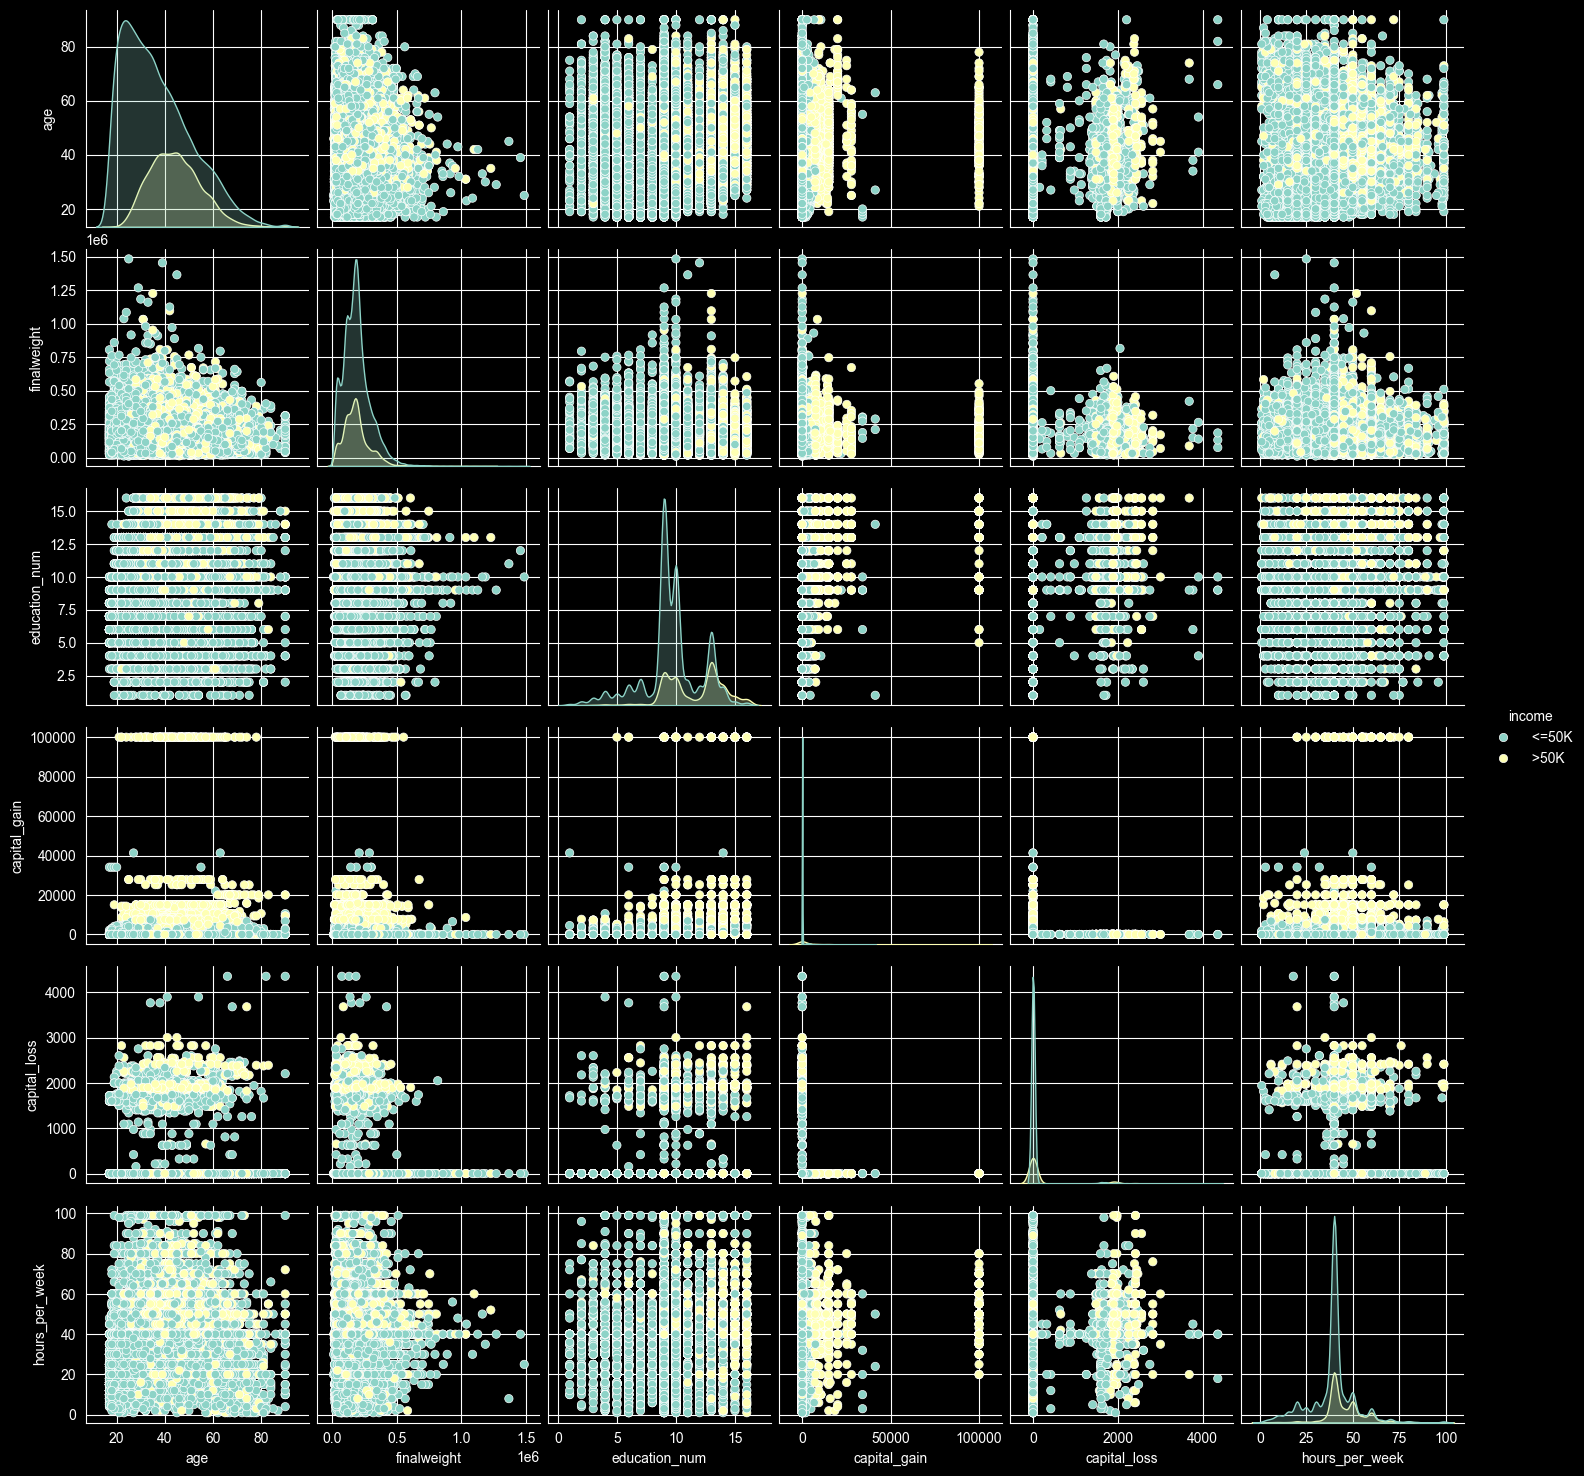

In [26]:
sns.pairplot(df, hue = "income")
plt.show()

In [27]:
X = df.drop("income", axis = 1)
y = df["income"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "O"]

In [30]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [31]:
X_train[categorical].isnull().sum()

workclass         1267
education            0
marital_status       0
occupation        1274
relationship         0
race                 0
sex                  0
native_country     405
dtype: int64

In [32]:
X_test[categorical].isnull().sum()

workclass         569
education           0
marital_status      0
occupation        569
relationship        0
race                0
sex                 0
native_country    178
dtype: int64

In [33]:
# ﷿﷿imdi bu eksik de﷿﷿erler categorical de﷿﷿i﷿﷿kenler i﷿﷿in en s﷿﷿k g﷿﷿r﷿﷿len de﷿﷿er ile doldurulacak. Bunun i﷿﷿in SimpleImputer s﷿﷿n﷿﷿f﷿﷿n﷿﷿ kullanaca﷿﷿﷿﷿z. Yani mod'a g﷿﷿re bo﷿﷿luklar﷿﷿ dolduraca﷿﷿﷿﷿z.

In [34]:
X_train['workclass'].mode()

0     Private
Name: workclass, dtype: object

In [35]:
for i in [X_train, X_test]:
    i['workclass'] = i['workclass'].fillna(X_train['workclass'].mode()[0])
    i['occupation'] = i['occupation'].fillna(X_train['occupation'].mode()[0])
    i['native_country'] = i['native_country'].fillna(X_train['native_country'].mode()[0])


In [36]:
X_train[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [37]:
X_test[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [38]:
df[categorical].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
dtype: int64

In [39]:
y_train_binary = y_train.apply(lambda x: 1 if x.strip() == '>50K' else 0)

In [40]:
y_train_binary

19749    0
1216     1
27962    0
23077    0
10180    0
        ..
29802    0
5390     0
860      0
15795    0
23654    0
Name: income, Length: 22792, dtype: int64

In [41]:
y_train_binary.groupby(X_train['native_country']).mean()

native_country
Cambodia                      0.357143
Canada                        0.321429
China                         0.192308
Columbia                      0.021739
Cuba                          0.246154
Dominican-Republic            0.039216
Ecuador                       0.050000
El-Salvador                   0.078947
England                       0.353846
France                        0.523810
Germany                       0.273684
Greece                        0.285714
Guatemala                     0.042553
Haiti                         0.093750
Holand-Netherlands            0.000000
Honduras                      0.000000
Hong                          0.454545
Hungary                       0.100000
India                         0.449275
Iran                          0.448276
Ireland                       0.222222
Italy                         0.360000
Jamaica                       0.160714
Japan                         0.425532
Laos                          0.083333
Mexico    

In [42]:
target_means = y_train_binary.groupby(X_train['native_country']).mean()

In [43]:
X_train['native_country_encoded'] = X_train['native_country'].map(target_means)
X_train['native_country_encoded'] = X_train['native_country_encoded'].fillna(target_means.mean())

X_test['native_country_encoded'] = X_test['native_country'].map(target_means)
X_test['native_country_encoded'] = X_test['native_country_encoded'].fillna(target_means.mean())

In [44]:
X_train.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
19749,34,Self-emp-not-inc,56460,HS-grad,9,Married-civ-spouse,Farming-fishing,Wife,White,Female,0,2179,12,United-States,0.248267
1216,48,Self-emp-not-inc,243631,Some-college,10,Married-civ-spouse,Craft-repair,Husband,Amer-Indian-Eskimo,Male,7688,0,40,United-States,0.248267
27962,23,State-gov,56402,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,30,United-States,0.248267
23077,56,Local-gov,255406,HS-grad,9,Divorced,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,0.248267
10180,17,Private,297246,11th,7,Never-married,Priv-house-serv,Own-child,White,Female,0,0,9,United-States,0.248267


In [45]:
X_train = X_train.drop("native_country", axis = 1)
X_test = X_test.drop("native_country", axis = 1)

In [46]:
one_hot_categories = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex']

In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [48]:
encoder = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories),
    ], remainder="passthrough"
)
# sparse_output=False parametresi, OneHotEncoder'﷿﷿n ﷿﷿﷿﷿kt﷿﷿s﷿﷿n﷿﷿ dense (yo﷿﷿un) bir NumPy array olarak d﷿﷿nd﷿﷿rmesini sa﷿﷿lar. Bu, ﷿﷿zellikle verilerinizin boyutu k﷿﷿﷿﷿﷿﷿kse veya modelinizin yo﷿﷿un bir formatta veri almas﷿﷿n﷿﷿ gerektiriyorsa kullan﷿﷿﷿﷿l﷿﷿d﷿﷿r. E﷿﷿er sparse_output=True olarak ayarlan﷿﷿rsa, ﷿﷿﷿﷿kt﷿﷿ sparse matrix format﷿﷿nda olur ve bu, b﷿﷿y﷿﷿k veri setlerinde bellek kullan﷿﷿m﷿﷿n﷿﷿ optimize edebilir.

In [49]:
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [50]:
X_test_enc

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        38.        ,  0.24826656],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24826656],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        55.        ,  0.24826656],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24826656],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24826656],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24826656]])

In [51]:
encoder.get_feature_names_out()

array(['OneHotEncoder__workclass_ Federal-gov',
       'OneHotEncoder__workclass_ Local-gov',
       'OneHotEncoder__workclass_ Never-worked',
       'OneHotEncoder__workclass_ Private',
       'OneHotEncoder__workclass_ Self-emp-inc',
       'OneHotEncoder__workclass_ Self-emp-not-inc',
       'OneHotEncoder__workclass_ State-gov',
       'OneHotEncoder__workclass_ Without-pay',
       'OneHotEncoder__education_ 10th', 'OneHotEncoder__education_ 11th',
       'OneHotEncoder__education_ 12th',
       'OneHotEncoder__education_ 1st-4th',
       'OneHotEncoder__education_ 5th-6th',
       'OneHotEncoder__education_ 7th-8th',
       'OneHotEncoder__education_ 9th',
       'OneHotEncoder__education_ Assoc-acdm',
       'OneHotEncoder__education_ Assoc-voc',
       'OneHotEncoder__education_ Bachelors',
       'OneHotEncoder__education_ Doctorate',
       'OneHotEncoder__education_ HS-grad',
       'OneHotEncoder__education_ Masters',
       'OneHotEncoder__education_ Preschool',
       'On

In [52]:
columns = encoder.get_feature_names_out()

In [53]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [54]:
X_train

,OneHotEncoder__workclass_ Federal-gov,OneHotEncoder__workclass_ Local-gov,OneHotEncoder__workclass_ Never-worked,OneHotEncoder__workclass_ Private,OneHotEncoder__workclass_ Self-emp-inc,OneHotEncoder__workclass_ Self-emp-not-inc,OneHotEncoder__workclass_ State-gov,OneHotEncoder__workclass_ Without-pay,OneHotEncoder__education_ 10th,OneHotEncoder__education_ 11th,...,OneHotEncoder__race_ White,OneHotEncoder__sex_ Female,OneHotEncoder__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
19749,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,34.0,56460.0,9.0,0.0,2179.0,12.0,0.248267
1216,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,48.0,243631.0,10.0,7688.0,0.0,40.0,0.248267
27962,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,23.0,56402.0,10.0,0.0,0.0,30.0,0.248267
23077,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,56.0,255406.0,9.0,0.0,0.0,40.0,0.248267
10180,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,17.0,297246.0,7.0,0.0,0.0,9.0,0.248267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,47.0,359461.0,13.0,0.0,0.0,40.0,0.248267
5390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,31.0,147215.0,8.0,0.0,0.0,21.0,0.248267
860,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,18.0,216284.0,7.0,0.0,0.0,20.0,0.248267
15795,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,50.0,54261.0,9.0,0.0,0.0,84.0,0.248267


In [55]:
cols = X_train.columns

In [56]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

In [57]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
X_test = pd.DataFrame(X_test, columns=cols)
X_train = pd.DataFrame(X_train, columns=cols)

In [59]:
X_train

,OneHotEncoder__workclass_ Federal-gov,OneHotEncoder__workclass_ Local-gov,OneHotEncoder__workclass_ Never-worked,OneHotEncoder__workclass_ Private,OneHotEncoder__workclass_ Self-emp-inc,OneHotEncoder__workclass_ Self-emp-not-inc,OneHotEncoder__workclass_ State-gov,OneHotEncoder__workclass_ Without-pay,OneHotEncoder__education_ 10th,OneHotEncoder__education_ 11th,...,OneHotEncoder__race_ White,OneHotEncoder__sex_ Female,OneHotEncoder__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.15,-1.018859,-0.333333,0.0,2179.0,-5.6,0.0
1,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.55,0.547177,0.000000,7688.0,0.0,0.0,0.0
2,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.70,-1.019344,0.000000,0.0,0.0,-2.0,0.0
3,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.95,0.645697,-0.333333,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,-1.0,-1.00,0.995766,-1.000000,0.0,0.0,-6.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.50,1.516311,1.000000,0.0,0.0,0.0,0.0
22788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.30,-0.259524,-0.666667,0.0,0.0,-3.8,0.0
22789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,-1.0,-0.95,0.318368,-1.000000,0.0,0.0,-4.0,0.0
22790,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.65,-1.037258,-0.333333,0.0,0.0,8.8,0.0


In [60]:
# trainning the model

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
rfc = RandomForestClassifier()

In [68]:
rfc = RandomForestClassifier(n_estimators=100, criterion="gini", min_samples_leaf=20, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=20, random_state=42)

In [69]:
y_pred = rfc.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [71]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8595557375371071
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7455
        >50K       0.77      0.58      0.66      2314

    accuracy                           0.86      9769
   macro avg       0.83      0.76      0.79      9769
weighted avg       0.85      0.86      0.85      9769

[[7063  392]
 [ 980 1334]]


In [72]:
rfc.feature_importances_

array([3.05620205e-03, 9.21566808e-04, 0.00000000e+00, 3.43571981e-03,
       2.76615069e-03, 4.96045149e-03, 4.68908892e-04, 0.00000000e+00,
       3.58682763e-04, 1.48546259e-03, 2.05890453e-05, 6.09727162e-05,
       4.99061024e-04, 2.24732102e-03, 9.41853906e-04, 6.54552234e-04,
       1.03701597e-03, 2.25802134e-02, 3.97299479e-03, 1.19950224e-02,
       1.45462738e-02, 0.00000000e+00, 7.25744462e-03, 4.74678210e-03,
       7.07381609e-03, 0.00000000e+00, 1.70229827e-01, 4.95718121e-05,
       4.83612217e-02, 8.73777064e-04, 6.43225493e-04, 1.76995440e-03,
       0.00000000e+00, 2.34005917e-03, 2.74566973e-02, 4.25832591e-03,
       1.34460543e-03, 2.12057327e-03, 5.28482645e-03, 2.54038009e-06,
       8.31979981e-03, 6.35864292e-04, 2.48857153e-03, 2.79426401e-03,
       1.23129409e-03, 9.10797188e-02, 1.93959552e-02, 4.53501994e-04,
       1.30509997e-02, 6.68912805e-03, 1.78266528e-02, 9.46641007e-08,
       2.11557324e-04, 9.28967053e-04, 1.40087924e-05, 1.26596341e-03,
      

In [74]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

In [75]:
feature_scores

OneHotEncoder__marital_status_ Married-civ-spouse    0.170230
remainder__capital_gain                              0.148314
remainder__education_num                             0.128150
OneHotEncoder__relationship_ Husband                 0.091080
remainder__age                                       0.077227
                                                       ...   
OneHotEncoder__education_ Preschool                  0.000000
OneHotEncoder__workclass_ Without-pay                0.000000
OneHotEncoder__marital_status_ Married-AF-spouse     0.000000
OneHotEncoder__workclass_ Never-worked               0.000000
OneHotEncoder__occupation_ Armed-Forces              0.000000
Length: 65, dtype: float64

In [78]:
feature_scores.tail()

OneHotEncoder__education_ Preschool                 0.0
OneHotEncoder__workclass_ Without-pay               0.0
OneHotEncoder__marital_status_ Married-AF-spouse    0.0
OneHotEncoder__workclass_ Never-worked              0.0
OneHotEncoder__occupation_ Armed-Forces             0.0
dtype: float64

In [79]:
# Hyperparameter tuning

In [80]:
from sklearn.model_selection import RandomizedSearchCV

In [82]:
rf_params = {
    "n_estimators": [100, 300, 650, 1000],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["auto", "sqrt", "log2", None, 5, 7, 9, 10],
    "max_depth": [5, 10, 15, 20, 25, None],
}

In [83]:
rfc = RandomForestClassifier()

In [84]:
rscv = RandomizedSearchCV(estimator=rfc, param_distributions=rf_params, n_iter=20, cv=5, verbose=10, n_jobs=-1)
rscv.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 5/5; 2/20] START criterion=entropy, max_depth=15, max_features=7, min_samples_leaf=10, min_samples_split=2, n_estimators=300
[CV 1/5; 1/20] START criterion=entropy, max_depth=5, max_features=9, min_samples_leaf=5, min_samples_split=5, n_estimators=650
[CV 1/5; 3/20] START criterion=gini, max_depth=5, max_features=7, min_samples_leaf=5, min_samples_split=10, n_estimators=1000
[CV 4/5; 1/20] START criterion=entropy, max_depth=5, max_features=9, min_samples_leaf=5, min_samples_split=5, n_estimators=650
[CV 3/5; 1/20] START criterion=entropy, max_depth=5, max_features=9, min_samples_leaf=5, min_samples_split=5, n_estimators=650
[CV 2/5; 2/20] START criterion=entropy, max_depth=15, max_features=7, min_samples_leaf=10, min_samples_split=2, n_estimators=300[CV 4/5; 2/20] START criterion=entropy, max_depth=15, max_features=7, min_samples_leaf=10, min_samples_split=2, n_estimators=300

[CV 3/5; 2/20] START criterion=entropy, max_

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 10, 15, 20, 25, None],
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         None, 5, 7, 9, 10],
                                        'min_samples_leaf': [5, 10, 20],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 300, 650, 1000]},
                   verbose=10)

In [85]:
y_pred = rscv.predict(X_test)

In [86]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8643668748080663
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7455
        >50K       0.77      0.60      0.68      2314

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.80      9769
weighted avg       0.86      0.86      0.86      9769

[[7048  407]
 [ 918 1396]]


In [87]:
rscv.best_params_

{'n_estimators': 650,
 'min_samples_split': 2,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'max_depth': 25,
 'criterion': 'gini'}